In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
df=pd.read_csv('fifa_world_cup_2026_player_performance.csv')

In [132]:
pd.set_option("display.max_columns",None)

In [133]:
df.shape

(54600, 75)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [135]:
summary=pd.DataFrame({'dtype':df.dtypes,
                     'missing':df.isna().sum(),
                     'unique':df.nunique()})
print("No of Integer columns =",(summary['dtype']=='int64').sum())
print("No of Categorical columns =",(summary['dtype']=='object').sum())
print("No of Float columns =",(summary['dtype']=='float64').sum())

No of Integer columns = 43
No of Categorical columns = 14
No of Float columns = 18


In [136]:
print("Missing values =",summary['missing'].sort_values(ascending=False).sum())

Missing values = 0


In [137]:
summary['unique'].sort_values(ascending=False).head(20)

player_id                   1248
market_value_eur            1246
player_name                 1245
match_id                    1050
offensive_contribution       981
defensive_contribution       941
creativity_score             941
clutch_performance_score     829
pressure_resistance          815
consistency_score            738
performance_score            639
total_minutes_tournament     586
stamina_score                491
possession_impact            308
expected_goals_xg            133
expected_assists_xa          130
club_name                    122
distance_covered_km          122
top_speed_kmh                112
total_passes                 101
Name: unique, dtype: int64

In [138]:
df.shape

(54600, 75)

In [139]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [140]:
player_info = ['player_id','player_name','age','nationality','jersey_number',
                'position','height_cm','weight_kg','preferred_foot']
match_info = ['team','club_name','match_id','match_date','stadium','city',
                'opponent_team','tournament_stage','match_result']
attacking = ['goals_team','goals_opponent','minutes_played','goals','assists',
                'shots','shots_on_target','expected_goals_xg','expected_assists_xa','key_passes']
passing = ['successful_passes','total_passes','pass_accuracy']
dribbling = ['dribbles_attempted','successful_dribbles','crosses','successful_crosses']
defensive = ['tackles','interceptions','clearances','blocks','aerial_duels_won',
            'aerial_duels_lost','recoveries','defensive_actions','fouls_committed',
            'fouls_suffered','yellow_cards','red_cards','offsides']
goalkeeping = ['saves','save_percentage','punches','clean_sheet','goals_conceded','penalty_saves']
physical = ['distance_covered_km','sprint_distance_km','top_speed_kmh','accelerations',
            'decelerations','stamina_score']
advanced_performance = ['player_rating','performance_score','offensive_contribution',
                        'defensive_contribution','possession_impact','pressure_resistance',
                        'creativity_score','consistency_score','clutch_performance_score']
tournament = ['total_goals_tournament','total_minutes_tournament','total_assists_tournament',
                'tournament_rating','player_of_match_awards']

In [141]:
df[player_info].select_dtypes(include='number').corrwith(df['market_value_eur']).sort_values(ascending=False)

jersey_number    0.187251
age             -0.068914
weight_kg       -0.073950
height_cm       -0.112356
dtype: float64

In [142]:
df[attacking].select_dtypes(include='number').corrwith(df['market_value_eur']).sort_values(ascending=False)

shots                  0.179431
key_passes             0.179169
shots_on_target        0.147591
expected_goals_xg      0.100588
expected_assists_xa    0.096156
goals                  0.093392
assists                0.081924
minutes_played         0.017773
goals_opponent         0.001612
goals_team            -0.003511
dtype: float64

In [143]:
df[passing].select_dtypes(include='number').corrwith(df['market_value_eur']).sort_values(ascending=False)

total_passes         0.197641
successful_passes    0.196165
pass_accuracy        0.019973
dtype: float64

In [144]:
df[dribbling].select_dtypes(include='number').corrwith(df['market_value_eur']).sort_values(ascending=False)

successful_dribbles    0.197640
dribbles_attempted     0.195985
successful_crosses     0.000374
crosses               -0.010841
dtype: float64

In [145]:
df[defensive].select_dtypes(include='number').corrwith(df['market_value_eur']).sort_values(ascending=False)

recoveries           0.129088
offsides             0.033182
fouls_suffered       0.010145
fouls_committed      0.007738
red_cards            0.005025
aerial_duels_lost   -0.000122
aerial_duels_won    -0.008618
tackles             -0.013522
blocks              -0.018984
yellow_cards        -0.019630
interceptions       -0.030630
defensive_actions   -0.044708
clearances          -0.064936
dtype: float64

In [146]:
df[goalkeeping].select_dtypes(include='number').corrwith(df['market_value_eur']).sort_values(ascending=False)

penalty_saves     -0.017085
clean_sheet       -0.032079
punches           -0.034521
goals_conceded    -0.039203
saves             -0.049353
save_percentage   -0.055765
dtype: float64

In [147]:
df[physical].select_dtypes(include='number').corrwith(df['market_value_eur']).sort_values(ascending=False)

stamina_score          0.089380
sprint_distance_km     0.025758
distance_covered_km    0.025671
top_speed_kmh          0.021983
accelerations          0.018317
decelerations          0.017190
dtype: float64

In [148]:
df[advanced_performance].select_dtypes(include='number').corrwith(df['market_value_eur']).sort_values(ascending=False)

consistency_score           0.624168
pressure_resistance         0.594907
offensive_contribution      0.530271
creativity_score            0.466853
possession_impact           0.347035
defensive_contribution      0.183273
clutch_performance_score    0.111797
performance_score           0.076187
player_rating               0.075153
dtype: float64

In [149]:
df[tournament].select_dtypes(include='number').corrwith(df['market_value_eur']).sort_values(ascending=False)

total_goals_tournament      0.121565
total_assists_tournament    0.088259
player_of_match_awards      0.088152
tournament_rating           0.074993
total_minutes_tournament    0.000860
dtype: float64

In [150]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [151]:
not_useful=['player_id','player_name','jersey_number','height_cm','weight_kg','club_name','match_id',
            'match_date','stadium','city','opponent_team','tournament_stage','match_result',
            'goals_team','goals_opponent','crosses','pass_accuracy','successful_passes',
            'dribbles_attempted','interceptions','clearances','blocks','aerial_duels_won',
            'aerial_duels_lost','defensive_actions','fouls_committed','fouls_suffered','saves',
            'save_percentage','punches','clean_sheet','goals_conceded','distance_covered_km',
            'sprint_distance_km','accelerations','decelerations','total_assists_tournament',
            'total_goals_tournament','total_minutes_tournament','tournament_rating','key_passes','pressure_resistance']

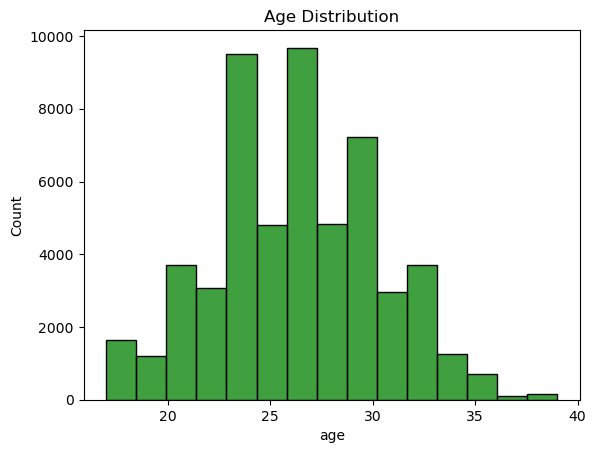

In [152]:
sns.histplot(data=df,x='age',bins=15,color='Green',edgecolor='black')
plt.title("Age Distribution")
plt.show()

In [153]:
print(f"Youngest player = {df['age'].min()} years")
print(f"Average Age= {df['age'].mean():.2f} years")
print(f"Oldest player= {df['age'].max()} years")

Youngest player = 17 years
Average Age= 26.30 years
Oldest player= 39 years


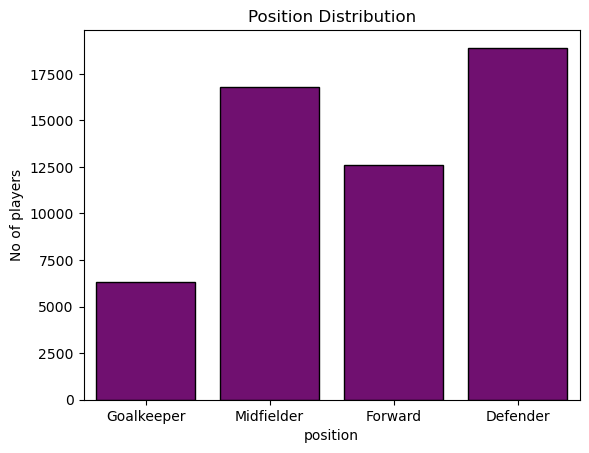

In [154]:
sns.countplot(data=df,x='position',color='Purple',edgecolor='black')
plt.ylabel("No of players")
plt.title("Position Distribution")
plt.show()

In [155]:
print(df['position'].value_counts(normalize=True).mul(100).round(2))

position
Defender      34.62
Midfielder    30.77
Forward       23.08
Goalkeeper    11.54
Name: proportion, dtype: float64


In [156]:
print(f"About {(df['position']=='Defender').sum()*100/len(df):.2f}% of players are Defender")

About 34.62% of players are Defender


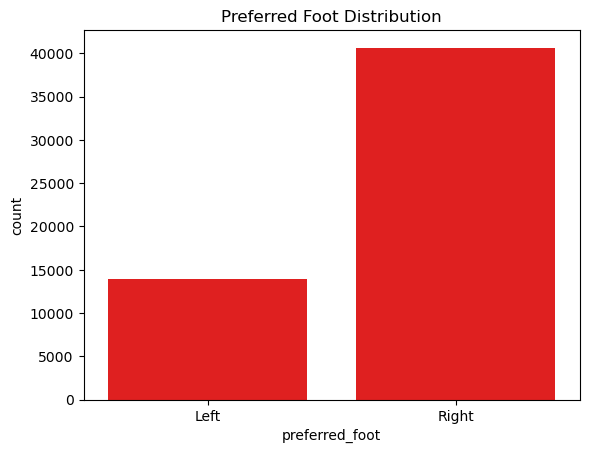

In [157]:
sns.countplot(data=df,x='preferred_foot',color='red')
plt.title("Preferred Foot Distribution")
plt.show()

In [158]:
print(f"About {(df['preferred_foot']=='Right').sum()*100/len(df):.2f}% of players are Right footed")
print(f"About {(df['preferred_foot']=='Left').sum()*100/len(df):.2f}% of players are Right footed")


About 74.46% of players are Right footed
About 25.54% of players are Right footed


In [159]:
df.groupby('player_name')['market_value_eur'].nunique().sort_values(ascending=False)

player_name
Hee-chan Hwang              2
Kalidou Mendy               2
Pierre-Emile Christensen    2
Aaron Metcalfe              1
Aaron Souttar               1
                           ..
Yassine Amrabat             1
Yassine Dari                1
Yassine El Yamiq            1
Yerry Barrios               1
Abdulrahman Al-Salem        1
Name: market_value_eur, Length: 1245, dtype: int64

In [160]:
df.groupby('player_name')['goals'].sum().sort_values(ascending=False)

player_name
Memphis Zerrouki    24
Kasey Hector        16
Eric Rodriguez      15
Vinicius Nunes      15
Mohannad Majeed     15
                    ..
Wataru Itakura       0
Wataru Ueda          0
Youssef Skhiri       0
Eden Dendoncker      0
Edinson Gimenez      0
Name: goals, Length: 1245, dtype: int64

In [161]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


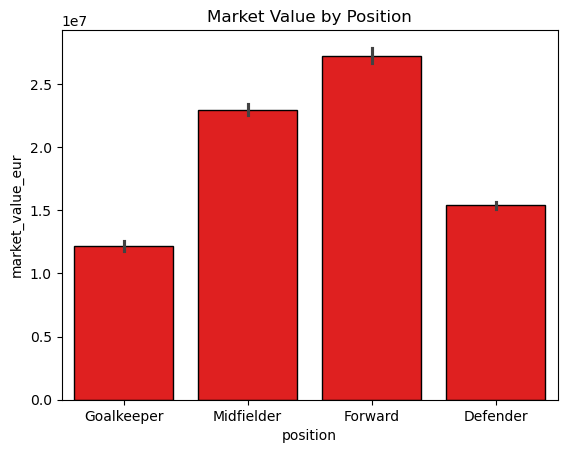

In [162]:
sns.barplot(data=df,y='market_value_eur',x='position',color='red',edgecolor='black')
plt.title("Market Value by Position")
plt.show()

In [163]:
print(f"Average Market value of Forward = {df[df['position']=='Forward']['market_value_eur'].mean():.3f} eur")

Average Market value of Forward = 27243386.005 eur


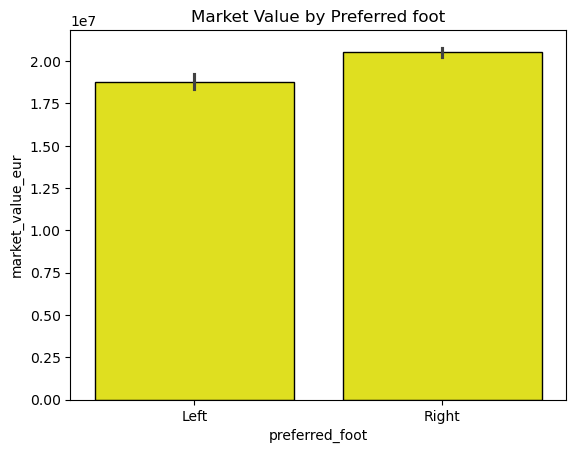

In [164]:
sns.barplot(data=df,x='preferred_foot',y='market_value_eur',color='yellow',edgecolor='black')
plt.title("Market Value by Preferred foot")
plt.show()

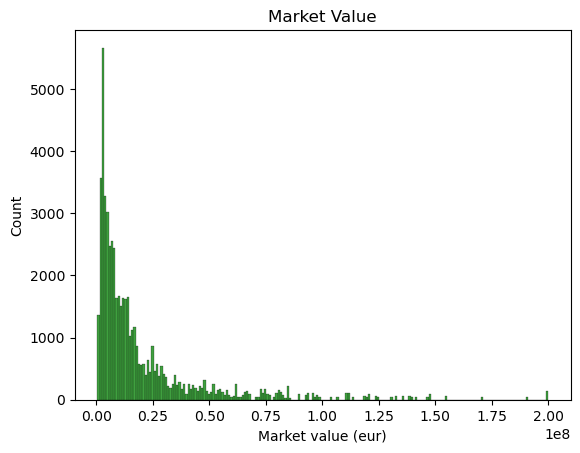

In [165]:
sns.histplot(data=df,x='market_value_eur',color='green')
plt.title('Market Value')
plt.xlabel("Market value (eur)")
plt.show()

In [166]:
print(f"The Average Market value of right footed players ({df[df['preferred_foot']=='Right']['market_value_eur'].mean():.2f}) is higher than left footed players ({df[df['preferred_foot']=='Left']['market_value_eur'].mean():.2f}). ")

The Average Market value of right footed players (20531175.09) is higher than left footed players (18781957.25). 


In [167]:
X=df.drop(columns=['market_value_eur'] + not_useful,axis=1)
y=df['market_value_eur']

In [168]:
#y=np.log1p(y)

In [169]:
X=pd.get_dummies(X,columns=['nationality','team','position','preferred_foot'],dtype='int')

In [170]:
X.head()

,age,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,total_passes,successful_dribbles,successful_crosses,tackles,recoveries,yellow_cards,red_cards,offsides,penalty_saves,top_speed_kmh,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,creativity_score,consistency_score,clutch_performance_score,player_of_match_awards,nationality_Algerian,nationality_American,nationality_Argentine,nationality_Australian,nationality_Austrian,nationality_Belgian,nationality_Brazilian,nationality_Cameroonian,nationality_Canadian,nationality_Chilean,nationality_Colombian,nationality_Costa Rican,nationality_Croatian,nationality_Danish,nationality_Dutch,nationality_Ecuadorian,nationality_Egyptian,nationality_English,nationality_French,nationality_German,nationality_Ghanaian,nationality_Iranian,nationality_Iraqi,nationality_Italian,nationality_Jamaican,nationality_Japanese,nationality_Mexican,nationality_Moroccan,nationality_Nigerian,nationality_Panamanian,nationality_Peruvian,nationality_Polish,nationality_Portuguese,nationality_Qatari,nationality_Saudi,nationality_Scottish,nationality_Senegalese,nationality_Serbian,nationality_South African,nationality_South Korean,nationality_Spanish,nationality_Swedish,nationality_Swiss,nationality_Tunisian,nationality_Turkish,nationality_Ukrainian,nationality_Uruguayan,nationality_Uzbek,team_Algeria,team_Argentina,team_Australia,team_Austria,team_Belgium,team_Brazil,team_Cameroon,team_Canada,team_Chile,team_Colombia,team_Costa Rica,team_Croatia,team_Denmark,team_Ecuador,team_Egypt,team_England,team_France,team_Germany,team_Ghana,team_Iran,team_Iraq,team_Italy,team_Jamaica,team_Japan,team_Mexico,team_Morocco,team_Netherlands,team_Nigeria,team_Panama,team_Peru,team_Poland,team_Portugal,team_Qatar,team_Saudi Arabia,team_Scotland,team_Senegal,team_Serbia,team_South Africa,team_South Korea,team_Spain,team_Sweden,team_Switzerland,team_Tunisia,team_Turkey,team_Ukraine,team_United States,team_Uruguay,team_Uzbekistan,position_Defender,position_Forward,position_Goalkeeper,position_Midfielder,preferred_foot_Left,preferred_foot_Right
0,26,72,0,0,0,0,0.00,0.00,26,0,0,0,0,0,0,0,0,26.5,81.9,5.6,50.9,3.3,48.2,1.1,55.9,42.0,51.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,19,90,0,0,0,0,0.01,0.00,40,0,0,0,2,0,0,0,0,29.0,85.5,5.7,55.9,37.9,29.4,3.5,43.7,31.1,52.7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
2,18,73,1,0,2,0,0.08,0.07,85,0,0,1,4,0,0,0,0,33.7,88.8,8.3,82.9,79.8,78.6,15.3,99.0,83.4,54.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,20,80,1,1,5,2,0.00,0.21,19,0,0,1,1,0,0,0,0,32.1,89.2,6.9,67.5,47.3,6.9,1.2,42.3,40.9,78.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1
4,23,79,0,0,1,0,0.00,0.00,44,1,0,1,4,0,0,0,0,30.5,73.6,5.7,55.4,33.0,75.6,6.2,33.5,60.0,56.6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [171]:
X.dtypes.value_counts()

int64      118
float64     12
Name: count, dtype: int64

In [172]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [173]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [174]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [175]:
model1=DecisionTreeRegressor(max_depth=10,min_samples_split=18,min_samples_leaf=3,random_state=42 )

In [176]:
model1.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=3, min_samples_split=18,
                      random_state=42)

In [177]:
y_pred=model1.predict(X_test)

In [178]:
model1.score(X_train,y_train)

0.7349109035434421

In [179]:
model1.score(X_test,y_test)

0.6638465653875414

In [180]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [191]:
print("MAE =",mean_absolute_error(y_test,y_pred))
print("RMSE =",np.sqrt(mean_squared_error(y_test,y_pred)))

MAE = 8361868.528086934
RMSE = 15750614.936545828


In [192]:
print("R2 Score =",r2_score(y_test,y_pred))

R2 Score = 0.6638465653875414


In [183]:
from sklearn.ensemble import RandomForestRegressor

In [184]:
model2 = RandomForestRegressor(n_estimators=200,random_state=42,min_samples_split=5,max_features='sqrt')

In [185]:
model2.fit(X_train,y_train)

RandomForestRegressor(max_features='sqrt', min_samples_split=5,
                      n_estimators=200, random_state=42)

In [186]:
y_pred2=model2.predict(X_test)

In [187]:
model2.score(X_train,y_train)

0.9407548444381165

In [188]:
model2.score(X_test,y_test)

0.7861849280821742

In [190]:
print("MAE =",mean_absolute_error(y_test,y_pred2))
print("RMSE =",np.sqrt(mean_squared_error(y_test,y_pred2)))
print("R2 Score =",r2_score(y_test,y_pred2))

MSE = 6836981.013215287
RMSE = 12561684.906814786
R2 Score = 0.7861849280821742


In [194]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12, 16],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 0.7]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

KeyboardInterrupt: 

In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Train R2:", best_model.score(X_train, y_train))
print("Test R2:", best_model.score(X_test, y_test))